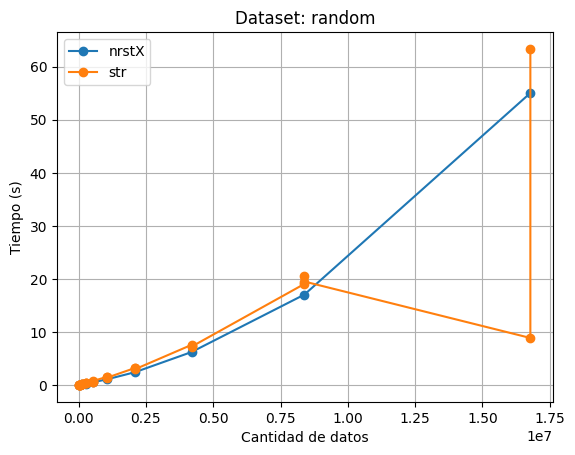

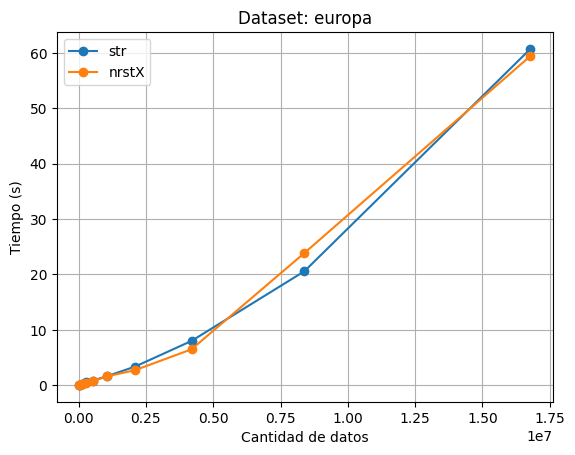

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Cargar datos
df = pd.read_csv("../tiempos.txt")

# Separar columna "archivo" en partes
# arbol_<dataset>_<modelo>
df[['arbol', 'dataset', 'modelo']] = df['archivo'].str.split('_', n=2, expand=True)

# Nos quedamos solo con dataset y modelo reales
df = df[['dataset', 'modelo', 'datos', 'tiempo']]

# Agrupar por dataset
datasets = df['dataset'].unique()

for dataset in datasets:
    subset = df[df['dataset'] == dataset]

    plt.figure()

    # Obtener modelos distintos dentro de ese dataset
    modelos = subset['modelo'].unique()

    for modelo in modelos:
        data_modelo = subset[subset['modelo'] == modelo]

        # Ordenar por cantidad de datos (importante para la curva)
        data_modelo = data_modelo.sort_values(by='datos')

        plt.plot(
            data_modelo['datos'],
            data_modelo['tiempo'],
            marker='o',
            label=modelo
        )

    plt.title(f"Dataset: {dataset}")
    plt.xlabel("Cantidad de datos")
    plt.ylabel("Tiempo (s)")
    plt.legend()
    plt.grid()

    # Guardar gráfico
    #plt.savefig(f"grafico_{dataset}.png")

    # Mostrar gráfico (opcional)
    plt.show()